Name : Utkarsh Vishwanath Parulekar             
   Roll no. CS39

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Auto MPG dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("auto-mpg.csv")

print(df.head())

df.head()

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Inspect and clean the data

In [ ]:
# Step 3: Inspect and clean data

print("Dataset Information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe())


# Remove rows with missing horsepower values

df = df.dropna(subset=['horsepower']).copy()

# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Remove any rows that became invalid
df = df.dropna(subset=['horsepower', 'mpg'])

print("Cleaned dataset shape:", df.shape)

display(df[['horsepower', 'mpg']].head())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Duplicate rows:
0

Statistical summary:


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


Cleaned dataset shape: (392, 9)


,horsepower,mpg
0,130.0,18.0
1,165.0,15.0
2,150.0,18.0
3,150.0,16.0
4,140.0,17.0


Select horsepower and MPG

In [ ]:
X = df[['horsepower']]
y = df['mpg']

# Display selected data
print("Horsepower (X):")
display(X.head())

print("MPG (y):")
display(y.head())

Horsepower (X):


,horsepower
0,130.0
1,165.0
2,150.0
3,150.0
4,140.0


MPG (y):


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [ ]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (392, 1)
Shape of y: (392,)


Plot scatter graph

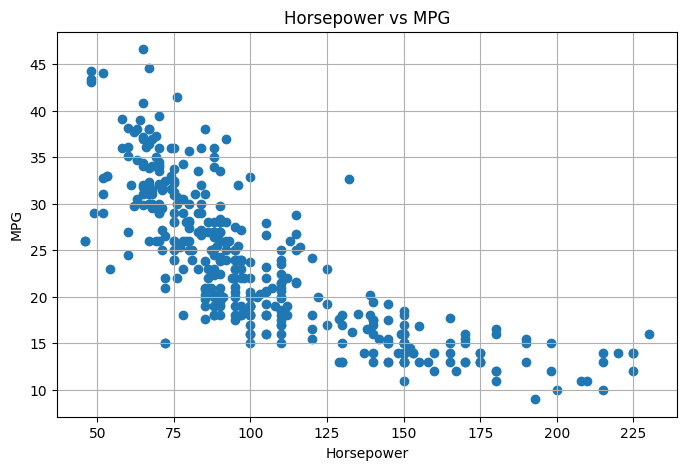

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('auto-mpg.csv')


df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower'])


plt.figure(figsize=(8, 5))

plt.scatter(df['horsepower'], df['mpg'])

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Horsepower vs MPG')
plt.grid(True)

plt.show()

Add bias/intercept term

In [ ]:
X = df[['horsepower']].values
X = np.c_[np.ones(X.shape[0]), X]
y = df['mpg'].values

print("X matrix with Bias Term:")
print(X[:5])

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

X matrix with Bias Term:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]

Shape of X: (392, 2)
Shape of y: (392,)


Compute correlation

In [ ]:
correlation = df['horsepower'].corr(df['mpg'])
print("Correlation between Horsepower and MPG:", correlation)

Correlation between Horsepower and MPG: -0.7784267838977756


Calculate OLS weights

In [ ]:
w = np.linalg.inv(X.T @ X) @ X.T @ y

print("OLS Weights:")
print(w)

print("\nIntercept (w0):", w[0])
print("Slope (w1):", w[1])

OLS Weights:
[39.93586102 -0.15784473]

Intercept (w0): 39.9358610211705
Slope (w1): -0.15784473335365387


Predict values

In [ ]:
y_pred = X @ w

print("Predicted MPG values:")
print(y_pred[:10])

Predicted MPG values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


Compute residuals

In [ ]:
residuals = y - y_pred

print("Residuals:")
print(residuals[:10])

Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [ ]:
print("First 10 Actual MPG:")
print(y[:10])

print("\nFirst 10 Predicted MPG:")
print(y_pred[:10])

print("\nFirst 10 Residuals:")
print(residuals[:10])

First 10 Actual MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

First 10 Predicted MPG:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]

First 10 Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


Calculate SSE, MSE and R²

In [ ]:
SSE = np.sum((y - y_pred) ** 2)

MSE = SSE / len(y)

SST = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - (SSE / SST)

print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


Plot regression and residual graphs

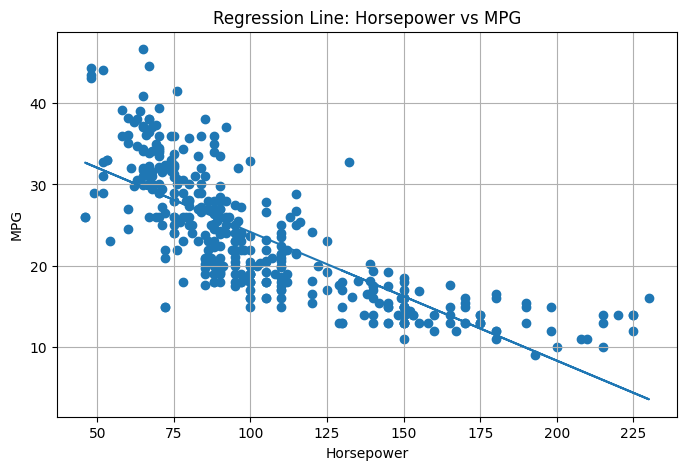

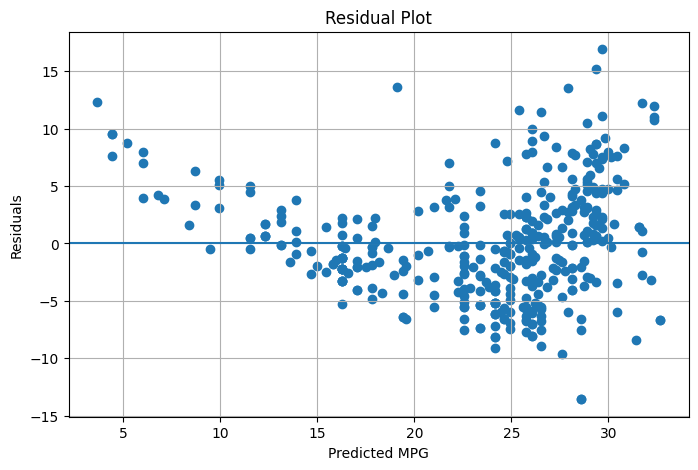

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['horsepower'], y)
plt.plot(df['horsepower'], y_pred)
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Regression Line: Horsepower vs MPG')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel('Predicted MPG')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

The Simple Linear Regression model was successfully used to predict MPG from Horsepower.

1. Horsepower and MPG have a **negative relationship**; as horsepower increases, MPG decreases.
2. The **OLS slope is negative**, confirming this relationship.
3. The regression graph shows a **downward-sloping line**.
4. **SSE** measures the total squared prediction error.
5. **MSE** measures the average prediction error; lower MSE indicates better accuracy.
6. **R²** shows how much MPG variation is explained by horsepower. A value around 0.60 indicates a significant relationship.
7. Residuals distributed around zero suggest that the **linear model is reasonably suitable**.
8. Overall, horsepower affects fuel efficiency, but factors like **weight, cylinders, displacement, and acceleration** also influence MPG.
